In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
np.random.seed(140)

In [2]:
x1 = np.random.uniform(1.0, 3.0, size=100)
x2 = np.random.uniform(1.0, 3.0, size=100)


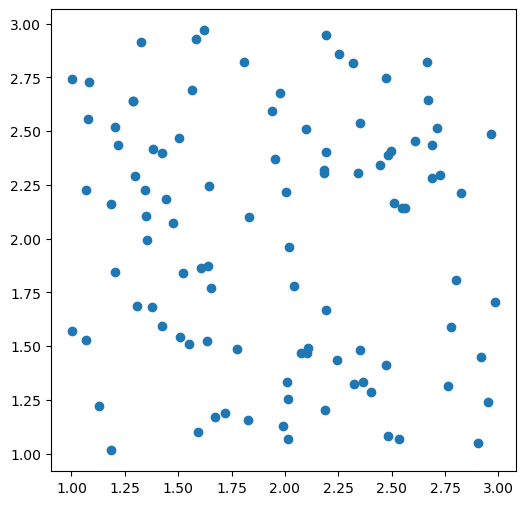

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(x1, x2)


In [4]:
import pandas as pd

In [5]:
d = {'x1':x1, 'x2':x2}
df = pd.DataFrame(data=d)

In [6]:
df

,x1,x2
0,2.495811,2.407477
1,1.217465,2.433010
2,1.001970,2.743038
3,1.593127,1.100096
4,1.003937,1.569088
...,...,...
95,2.664759,2.819450
96,2.953516,1.240042
97,2.319406,2.817151
98,2.472055,1.411997


In [11]:
y = [0 if i < 1.15 else 1 for i in x1]

In [18]:
y = np.array(y)

In [19]:
y[x2 < 1.47] = y[x2 < 1.47] * 0

In [20]:
y

array([1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1])

In [22]:
y[x2 > 2.55] = y[x2 > 2.55] * 0

In [27]:
y[x1 > 2.875] = y[x1 > 2.875] * 0

In [28]:
y

array([1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1])

In [29]:
o = y == 0
plus = y == 1


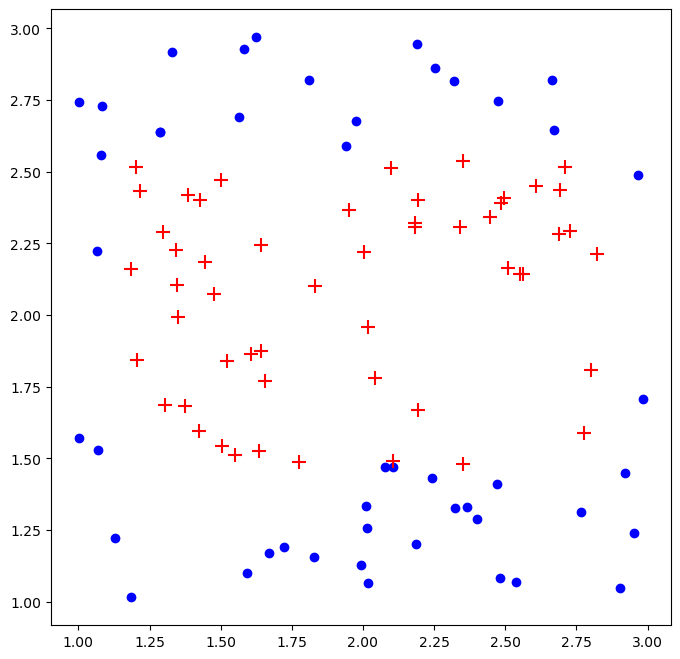

In [35]:

plt.figure(figsize=(8,8))

plt.scatter(x1[o], x2[o], marker='o', color='blue', label='y=0')

# Plot points where y=1 as plus signs
plt.scatter(x1[plus], x2[plus], marker='+', color='red', s=100, label='y=1')

In [31]:
df['label'] = y

In [32]:
df

,x1,x2,label
0,2.495811,2.407477,1
1,1.217465,2.433010,1
2,1.001970,2.743038,0
3,1.593127,1.100096,0
4,1.003937,1.569088,0
...,...,...,...
95,2.664759,2.819450,0
96,2.953516,1.240042,0
97,2.319406,2.817151,0
98,2.472055,1.411997,0


In [36]:
# df.to_csv('inital.csv', index=True)

In [172]:
df = pd.read_csv('inital.csv')

In [173]:
y = df['y']

In [174]:
x1 = df['x1']
x2 = df['x2']

In [175]:
o = y == 0
plus = y == 1

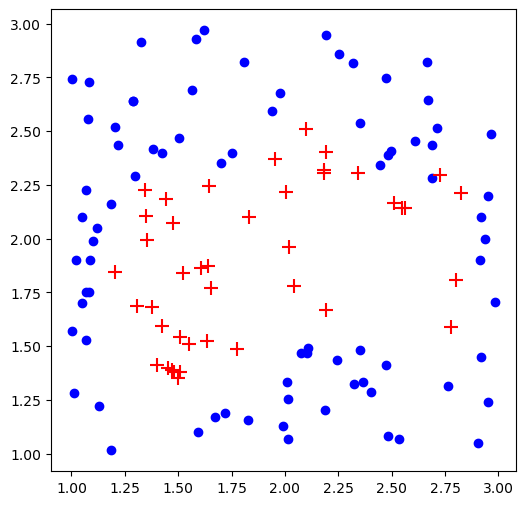

In [176]:

plt.figure(figsize=(6,6))

plt.scatter(x1[o], x2[o], marker='o', color='blue', label='y=0')

# Plot points where y=1 as plus signs
plt.scatter(x1[plus], x2[plus], marker='+', color='red', s=100, label='y=1')

In [177]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

Feature importances: x1 = 0.4434, x2 = 0.5566

Decision Rules:
Node 0: If x2 <= 2.4046 then go to node 1 else go to node 8
Node 1: If x2 <= 1.3414 then go to node 2 else go to node 3
Node 2: Leaf node - Predicted class: 0 (probability: 1.0000)
Node 3: If x1 <= 1.1952 then go to node 4 else go to node 5
Node 4: Leaf node - Predicted class: 0 (probability: 1.0000)
Node 5: If x1 <= 2.8692 then go to node 6 else go to node 7
Node 6: Leaf node - Predicted class: 1 (probability: 0.7593)
Node 7: Leaf node - Predicted class: 0 (probability: 1.0000)
Node 8: If x2 <= 2.5138 then go to node 9 else go to node 12
Node 9: If x2 <= 2.4998 then go to node 10 else go to node 11
Node 10: Leaf node - Predicted class: 0 (probability: 1.0000)
Node 11: Leaf node - Predicted class: 1 (probability: 1.0000)
Node 12: Leaf node - Predicted class: 0 (probability: 1.0000)


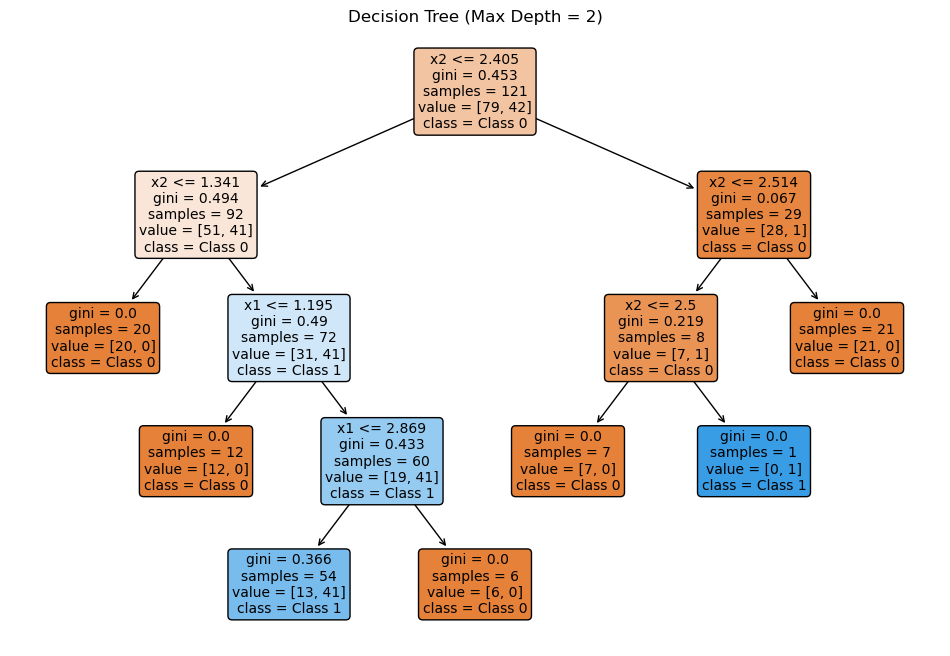

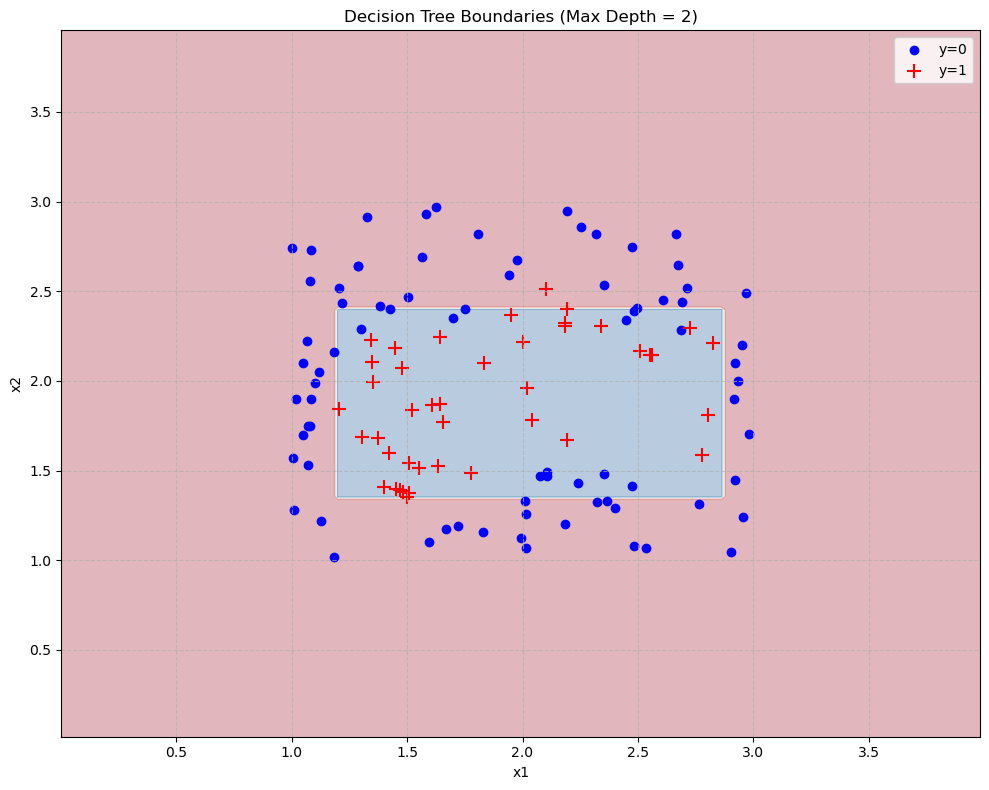

In [178]:
X = np.column_stack((x1, x2))

# Create a decision tree classifier with max depth of 2
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the classifier
clf.fit(X, y)

# Create a figure
plt.figure(figsize=(12, 8))

# Plot the decision tree
plot_tree(clf, 
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree (Max Depth = 2)')

# Let's also visualize the decision boundaries in the feature space
plt.figure(figsize=(10, 8))

# Create a meshgrid to plot the decision boundaries
h = 0.02  # Step size
x1_min, x1_max = x1.min() - 1, x1.max() + 1
x2_min, x2_max = x2.min() - 1, x2.max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                       np.arange(x2_min, x2_max, h))

# Make predictions on the meshgrid
Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

# Plot the decision boundaries
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plot the original data points
zeros = y == 0
ones = y == 1
plt.scatter(x1[zeros], x2[zeros], marker='o', color='blue', label='y=0')
plt.scatter(x1[ones], x2[ones], marker='+', color='red', s=100, label='y=1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Tree Boundaries (Max Depth = 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show feature importances
importances = clf.feature_importances_
print(f"Feature importances: x1 = {importances[0]:.4f}, x2 = {importances[1]:.4f}")

# Extract and display decision rules
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold
value = clf.tree_.value

print("\nDecision Rules:")
for i in range(n_nodes):
    if children_left[i] != children_right[i]:  # This is a split node
        feature_name = ['x1', 'x2'][feature[i]]
        print(f"Node {i}: If {feature_name} <= {threshold[i]:.4f} then go to node {children_left[i]} else go to node {children_right[i]}")
    else:  # This is a leaf node
        class_prob = value[i][0] / value[i][0].sum()
        predicted_class = np.argmax(class_prob)
        print(f"Node {i}: Leaf node - Predicted class: {predicted_class} (probability: {class_prob[predicted_class]:.4f})")

plt.tight_layout()
plt.show()

In [179]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [241]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)

# Define a simple single-layer neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 2),
            nn.ReLU(),
            nn.Linear(2, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            # Sigmoid activation for binary classification (outputs between 0 and 1)
            nn.Sigmoid()
        )
    def forward(self, x):
        # Forward pass through the network
        return self.model(x)

# Prepare data from pandas DataFrame
def prepare_data(df, x_cols=['x1', 'x2'], y_col='y', test_size=0.2):
    """
    Prepare data from pandas DataFrame for PyTorch model
    
    Args:
        df: pandas DataFrame containing the data
        x_cols: list of column names for features
        y_col: column name for the target variable
        test_size: proportion of data to use for testing
        
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    """
    # Extract features and target
    X = df[x_cols].values
    y = df[y_col].values.reshape(-1, 1)
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    print(len(X))
    # Scale features (optional but often helps training)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test)
    
    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, scaler

# Training function
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.04, batch_size=None):
    # Define loss function and optimizer
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # Lists to store loss history
    train_losses = []
    test_losses = []
    
    # Training loop
    for epoch in range(epochs):
        # Forward pass
        outputs = model(X_train)
        train_loss = criterion(outputs, y_train)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # Calculate test loss
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses.append(test_loss.item())
        
        # Record loss
        train_losses.append(train_loss.item())
        
        # Print progress
        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
    
    return train_losses, test_losses

# Evaluate the model
def evaluate_model(model, X_test, y_test):
    with torch.no_grad():
        # Get predictions
        y_pred = model(X_test)
        
        # Convert predictions to binary (0 or 1)
        y_pred_binary = (y_pred > 0.5).float()
        
        # Calculate accuracy
        accuracy = (y_pred_binary == y_test).float().mean().item()
        
        print(f'Test Accuracy: {accuracy:.4f}')
        
        # Calculate confusion matrix values
        true_positives = ((y_pred_binary == 1) & (y_test == 1)).float().sum().item()
        false_positives = ((y_pred_binary == 1) & (y_test == 0)).float().sum().item()
        true_negatives = ((y_pred_binary == 0) & (y_test == 0)).float().sum().item()
        false_negatives = ((y_pred_binary == 0) & (y_test == 1)).float().sum().item()
        
        print("Confusion Matrix:")
        print(f"True Positives: {true_positives}, False Positives: {false_positives}")
        print(f"True Negatives: {true_negatives}, False Negatives: {false_negatives}")
    
    return accuracy

# Visualize decision boundary
def plot_decision_boundary(model, X, y, scaler, feature_names=['x1', 'x2']):
    # Create a mesh grid to visualize the decision boundary
    x1_min, x1_max = 1.0, 3
    x2_min, x2_max = 1, 3
    h = 0.01
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    
    # Scale mesh grid points
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    scaled_grid_points = scaler.transform(grid_points)
    
    # Predict for each point in the mesh grid
    Z = model(torch.FloatTensor(scaled_grid_points))
    Z = Z.detach().numpy().reshape(xx1.shape)
    Z = (Z > 0.5).astype(int)
    # Plot decision boundary and data points
    plt.figure(figsize=(10, 8))
    plt.contourf(xx1, xx2, Z, alpha=0.8, cmap=plt.cm.RdBu)
    
    # Get original data (unscaled) for plotting
    original_data = scaler.inverse_transform(X.numpy())
    plt.scatter(original_data[:, 0], original_data[:, 1], c=y.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
    
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Decision Boundary')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Plot the loss curves
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Main execution
def main(df, x_columns=['x1', 'x2'], y_column='y'):
    # Prepare data
    X_train, X_test, y_train, y_test, scaler = prepare_data(
        df, x_cols=x_columns, y_col=y_column, test_size=0.01
    )
    
    # Initialize the model
    input_size = len(x_columns)
    model = SimpleNN(input_size)
    
    # Train the model
    train_losses, test_losses = train_model(
        model, X_train, y_train, X_test, y_test, 
        epochs=1000, lr=0.1
    )
    
    # Plot the loss curves
    plot_losses(train_losses, test_losses)
    
    # Evaluate the model
    evaluate_model(model, X_train, y_train)
    # Get predictions
    if len(x_columns) == 2:
        plot_decision_boundary(model, X_train, y_train, scaler, feature_names=x_columns)
    
    # Print model parameters
    print("\nModel parameters:")
    for name, param in model.named_parameters():
        print(f"{name}: {param.data}")
    X_train, X_test, y_train, y_test, scaler = prepare_data(
        df, x_cols=x_columns, y_col=y_column, test_size=0.05
    )
    y_predt = model(X_train)
    
    # Convert predictions to binary (0 or 1)
    y_pred_binary = (y_predt > 0.5).float()
    o = y_pred_binary == 0
    plus = y_pred_binary == 1
    print(o)
    original_data = scaler.inverse_transform(X_train.numpy())
    plt.figure(figsize=(6,6))
    #plt.scatter(original_data[:, 0], original_data[:, 1], c=y_pred_binary.squeeze(), edgecolors='k', cmap=plt.cm.RdBu)
    plt.scatter(original_data[o.reshape(-1,), 0], original_data[o.reshape(-1,), 1], marker='o', color='blue', label='y=0')

    # Plot points where y=1 as plus signs
    plt.scatter(original_data[plus.reshape(-1,), 0], original_data[plus.reshape(-1,), 1], marker='+', color='red', s=100, label='y=1')
    # Plot the decision boundary (only if we have 2 features)
    
    
    return model, scaler

# Example usage (uncomment and modify as needed)
"""
# Assuming you have a pandas DataFrame named 'df' with columns 'x1', 'x2', and 'y'
# Example:
# df = pd.DataFrame({
#     'x1': np.random.uniform(1, 3, 100),
#     'x2': np.random.uniform(1, 3, 100),
#     'y': np.random.randint(0, 2, 100)
# })

# Train the model
model, scaler = main(df)

# Make predictions on new data
new_data = pd.DataFrame({
    'x1': [1.5, 2.5, 1.5, 2.5],
    'x2': [1.5, 1.5, 2.5, 2.5]
})

# Scale the new data
scaled_new_data = scaler.transform(new_data)

# Convert to tensor and predict
with torch.no_grad():
    predictions = model(torch.FloatTensor(scaled_new_data))
    
print("\nPredictions on new data:")
for i, (_, row), pred in zip(range(len(new_data)), new_data.iterrows(), predictions):
    print(f"Sample {i+1}: x1={row['x1']:.1f}, x2={row['x2']:.1f} → Prediction: {pred.item():.4f}, Class: {round(pred.item())}")
"""

'\n# Assuming you have a pandas DataFrame named \'df\' with columns \'x1\', \'x2\', and \'y\'\n# Example:\n# df = pd.DataFrame({\n#     \'x1\': np.random.uniform(1, 3, 100),\n#     \'x2\': np.random.uniform(1, 3, 100),\n#     \'y\': np.random.randint(0, 2, 100)\n# })\n\n# Train the model\nmodel, scaler = main(df)\n\n# Make predictions on new data\nnew_data = pd.DataFrame({\n    \'x1\': [1.5, 2.5, 1.5, 2.5],\n    \'x2\': [1.5, 1.5, 2.5, 2.5]\n})\n\n# Scale the new data\nscaled_new_data = scaler.transform(new_data)\n\n# Convert to tensor and predict\nwith torch.no_grad():\n    predictions = model(torch.FloatTensor(scaled_new_data))\n    \nprint("\nPredictions on new data:")\nfor i, (_, row), pred in zip(range(len(new_data)), new_data.iterrows(), predictions):\n    print(f"Sample {i+1}: x1={row[\'x1\']:.1f}, x2={row[\'x2\']:.1f} → Prediction: {pred.item():.4f}, Class: {round(pred.item())}")\n'

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  121 non-null    int64  
 1   x1          121 non-null    float64
 2   x2          121 non-null    float64
 3   y           121 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.9 KB
None

Sample data:
   Unnamed: 0        x1        x2  y
0           0  2.495811  2.407477  0
1           1  1.217465  2.433010  0
2           2  1.001970  2.743038  0
3           3  1.593127  1.100096  0
4           4  1.003937  1.569088  0

Target distribution:
y
0    79
1    42
Name: count, dtype: int64

Training model...
121
Epoch [100/1000], Train Loss: 0.5974, Test Loss: 0.8277
Epoch [200/1000], Train Loss: 0.5821, Test Loss: 0.8527
Epoch [300/1000], Train Loss: 0.5733, Test Loss: 0.8315
Epoch [400/1000], Train Loss: 0.5652, Test Loss: 0.8102
Epoch [500/1000], Train

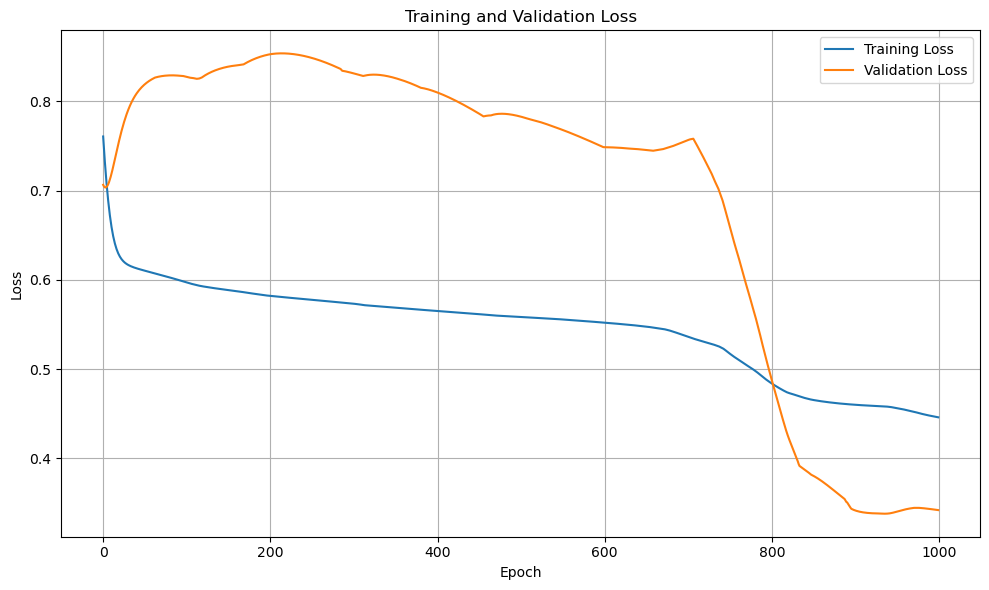

Test Accuracy: 0.7899
Confusion Matrix:
True Positives: 31.0, False Positives: 15.0
True Negatives: 63.0, False Negatives: 10.0


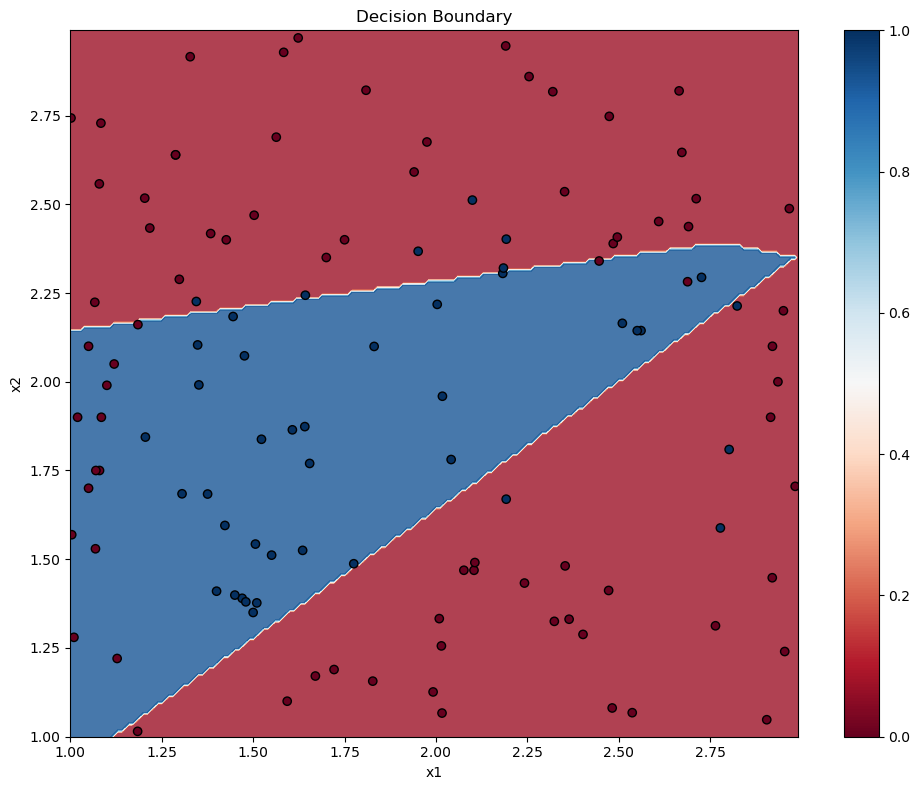


Model parameters:
model.0.weight: tensor([[ 0.7821, -0.9656],
        [-0.2544,  1.6452]])
model.0.bias: tensor([-0.3842, -0.7246])
model.2.weight: tensor([[1.0695, 1.7316]])
model.2.bias: tensor([0.1597])
model.4.weight: tensor([[-2.0053]])
model.4.bias: tensor([1.0406])
121
tensor([[ True],
        [ True],
        [False],
        [ True],
        [False],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [False],
        [ True],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [ True],
        [ True],
        [ True],
        [ True],
        [False],
        [False],
        [False],
        [False],
        [False],
        

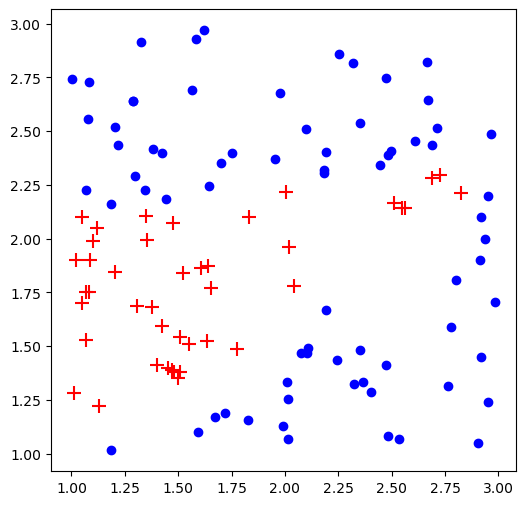

In [242]:
import pandas as pd


# Assuming your DataFrame is already loaded and has the right columns
# Replace this with your actual code to load your DataFrame
# df = pd.read_csv('your_data.csv')  # Example loading data from CSV

# For this example, I'll create a small sample DataFrame
# REPLACE THIS WITH YOUR ACTUAL DATAFRAME
# import numpy as np
# np.random.seed(42)
# df = pd.DataFrame({
#     'x1': np.random.uniform(1, 3, 100),
#     'x2': np.random.uniform(1, 3, 100),
#     'y': np.random.randint(0, 2, 100)
# })

# Print dataframe info
print("DataFrame information:")
print(df.info())
print("\nSample data:")
print(df.head())
print("\nTarget distribution:")
print(df['y'].value_counts())

# Train the model
print("\nTraining model...")
model, scaler = main(
    df=df,
    x_columns=['x1', 'x2'],  # These should match your column names
    y_column='y'             # This should match your label column name
)

# # Now you can use the model to make predictions on new data
# new_data = pd.DataFrame({
#     'x1': [1.5, 2.5, 1.5, 2.5],
#     'x2': [1.5, 1.5, 2.5, 2.5]
# })

# # Scale the new data
# scaled_new_data = scaler.transform(new_data)

# # Convert to tensor and predict
# import torch
# with torch.no_grad():
#     predictions = model(torch.FloatTensor(scaled_new_data))
    
# print("\nPredictions on new data:")
# for i, (_, row), pred in zip(range(len(new_data)), new_data.iterrows(), predictions):
#     print(f"Sample {i+1}: x1={row['x1']:.1f}, x2={row['x2']:.1f} → "
#           f"Prediction: {pred.item():.4f}, Class: {round(pred.item())}")